# Unit14_Example_02 | 化工案例二：不同催化劑批次反應收率之假設檢定

本 Notebook 示範如何對兩組獨立樣本（催化劑 A 與 B 的反應收率）進行完整的假設檢定分析流程。

## 目標
- 計算並視覺化兩組樣本均值的 $95\%$ 信賴區間（`scipy.stats.t.interval()`）
- 使用 Levene 檢定（`scipy.stats.levene()`）評估兩組變異數是否齊一
- 根據 Levene 結果，執行適當形式的獨立兩樣本 t 檢定（`scipy.stats.ttest_ind()`）
- 計算效果量 Cohen's $d$ ，區分統計顯著與實際顯著
- 繪製箱型圖與帶狀圖進行視覺比較

---
### 0. 環境設定

In [20]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_02\figs


---
### 1. 載入套件

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy, matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與模擬數據生成

**問題描述**  
工廠欲評估新型催化劑 B 是否顯著優於現有催化劑 A，分別取各 20 批實驗數據進行統計比較，顯著水準 $\alpha = 0.05$ （單尾檢定）。

| 組別 | 催化劑 | 設定均值 | 設定標準差 | 樣本數 |
|------|--------|----------|------------|--------|
| A | 現有催化劑 | 82 % | 2.5 % | 20 |
| B | 新型催化劑 | 85 % | 2.8 % | 20 |

**假設**：
- $H_0: \mu_B - \mu_A \le 0$ （催化劑 B 不優於 A）
- $H_1: \mu_B - \mu_A > 0$ （催化劑 B 優於 A）

In [22]:
# ============================================================
# 模擬數據生成
# ============================================================
rng = np.random.default_rng(42)

n_A, n_B = 20, 20
mu_A_true, sigma_A = 82.0, 2.5  # 催化劑 A
mu_B_true, sigma_B = 85.0, 2.8  # 催化劑 B

yield_A = rng.normal(loc=mu_A_true, scale=sigma_A, size=n_A)
yield_B = rng.normal(loc=mu_B_true, scale=sigma_B, size=n_B)

# 描述統計
mean_A, std_A = np.mean(yield_A), np.std(yield_A, ddof=1)
mean_B, std_B = np.mean(yield_B), np.std(yield_B, ddof=1)

print("=" * 50)
print("  描述統計摘要")
print("=" * 50)
print(f"{'指標':<20} {'催化劑 A':>12} {'催化劑 B':>12}")
print("-" * 50)
print(f"{'樣本數 n':<20} {n_A:>12} {n_B:>12}")
print(f"{'樣本均值 (mean)':<20} {mean_A:>12.4f} {mean_B:>12.4f}")
print(f"{'樣本標準差 (std)':<20} {std_A:>12.4f} {std_B:>12.4f}")
print(f"{'最小值 (min)':<20} {yield_A.min():>12.4f} {yield_B.min():>12.4f}")
print(f"{'最大值 (max)':<20} {yield_A.max():>12.4f} {yield_B.max():>12.4f}")
print("=" * 50)
print(f"\n均值差異 (B - A) = {mean_B - mean_A:.4f} %")

  描述統計摘要
指標                          催化劑 A        催化劑 B
--------------------------------------------------
樣本數 n                          20           20
樣本均值 (mean)               81.9177      85.3065
樣本標準差 (std)                2.1754       2.2261
最小值 (min)                 77.1224      82.6476
最大值 (max)                 84.8181      90.9966

均值差異 (B - A) = 3.3888 %


---
### 3. 信賴區間計算與視覺化

使用 `scipy.stats.t.interval()` 計算各組樣本均值的 $95\%$ 信賴區間：

$$
\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}
$$

95% 信賴區間 (基於 t 分布)
-------------------------------------------------------
催化劑 A:  (80.8995, 82.9358)  半寬 = 1.0181
催化劑 B:  (84.2647, 86.3483)  半寬 = 1.0418
-------------------------------------------------------

兩組 95% CI 是否重疊: 否（完全分離）
  → 信賴區間不重疊，強烈暗示兩組均值有顯著差異


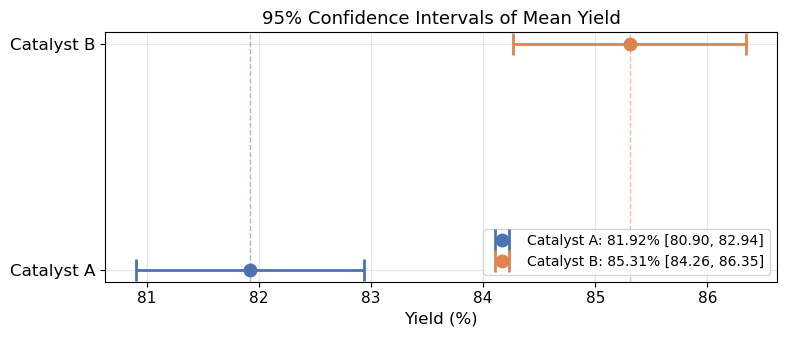

✓ 圖檔儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_02\figs\confidence_intervals.png


In [23]:
# ============================================================
# 計算 95% 信賴區間 using scipy.stats.t.interval()
# ============================================================
se_A = stats.sem(yield_A)   # 標準誤 = std / sqrt(n)
se_B = stats.sem(yield_B)

ci_A = stats.t.interval(confidence=0.95, df=n_A - 1, loc=mean_A, scale=se_A)
ci_B = stats.t.interval(confidence=0.95, df=n_B - 1, loc=mean_B, scale=se_B)

print("95% 信賴區間 (基於 t 分布)")
print("-" * 55)
print(f"催化劑 A:  ({ci_A[0]:.4f}, {ci_A[1]:.4f})  半寬 = {(ci_A[1]-ci_A[0])/2:.4f}")
print(f"催化劑 B:  ({ci_B[0]:.4f}, {ci_B[1]:.4f})  半寬 = {(ci_B[1]-ci_B[0])/2:.4f}")
print("-" * 55)

# 判斷區間是否重疊
overlap = ci_A[1] > ci_B[0]
print(f"\n兩組 95% CI 是否重疊: {'是' if overlap else '否（完全分離）'}")
if overlap:
    print("  → 信賴區間部分重疊，不能直接從視覺判斷，需執行正式 t 檢定")
else:
    print("  → 信賴區間不重疊，強烈暗示兩組均值有顯著差異")

# ---- 視覺化：信賴區間圖 ----
fig, ax = plt.subplots(figsize=(8, 3.5))

colors = ['#4C72B0', '#DD8452']
labels = ['Catalyst A', 'Catalyst B']
means  = [mean_A, mean_B]
cis    = [ci_A, ci_B]

for i, (lbl, m, ci, c) in enumerate(zip(labels, means, cis, colors)):
    ax.errorbar(m, i + 1,
                xerr=[[m - ci[0]], [ci[1] - m]],
                fmt='o', color=c, capsize=8, capthick=2, ms=9,
                label=f'{lbl}: {m:.2f}% [{ci[0]:.2f}, {ci[1]:.2f}]')

ax.set_yticks([1, 2])
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Yield (%)')
ax.set_title('95% Confidence Intervals of Mean Yield')
ax.legend(loc='lower right', fontsize=10)
ax.axvline(mean_A, color=colors[0], ls='--', lw=1, alpha=0.5)
ax.axvline(mean_B, color=colors[1], ls='--', lw=1, alpha=0.5)
plt.tight_layout()

fig_path = FIG_DIR / 'confidence_intervals.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔儲存: {fig_path}")

---
### 4. Levene 變異數齊一性檢定

在執行獨立兩樣本 t 檢定之前，先以 Levene 檢定評估兩組變異數是否相等，以決定應選用：
- **Pooled-variance t-test** (`equal_var=True`)：適用於 $\sigma_A^2 = \sigma_B^2$ （等變異數）
- **Welch's t-test** (`equal_var=False`)：適用於 $\sigma_A^2 \ne \sigma_B^2$ ，更具穩健性

$$
H_0: \sigma_A^2 = \sigma_B^2 \qquad H_1: \sigma_A^2 \ne \sigma_B^2
$$

In [24]:
# ============================================================
# Levene 變異數齊一性檢定
# ============================================================
stat_levene, p_levene = stats.levene(yield_A, yield_B)

print("Levene 變異數齊一性檢定 (H0: σ_A² = σ_B²)")
print("-" * 50)
print(f"Levene W 統計量 = {stat_levene:.4f}")
print(f"p 值            = {p_levene:.4f}")
print("-" * 50)

alpha = 0.05
if p_levene < alpha:
    use_equal_var = False
    conclusion_levene = f"p = {p_levene:.4f} < α = {alpha}，拒絕 H0"
    method_str = "Welch's t-test (equal_var=False)"
    print(f"結論: {conclusion_levene}")
    print(f"  → 兩組變異數有顯著差異，採用 {method_str}")
else:
    use_equal_var = True
    conclusion_levene = f"p = {p_levene:.4f} ≥ α = {alpha}，不拒絕 H0"
    method_str = "Pooled-variance t-test (equal_var=True)"
    print(f"結論: {conclusion_levene}")
    print(f"  → 兩組變異數無顯著差異，採用 {method_str}")

print(f"\n樣本變異數對比：Var(A) = {std_A**2:.4f}，Var(B) = {std_B**2:.4f}，比值 = {std_B**2/std_A**2:.4f}")

Levene 變異數齊一性檢定 (H0: σ_A² = σ_B²)
--------------------------------------------------
Levene W 統計量 = 0.0030
p 值            = 0.9568
--------------------------------------------------
結論: p = 0.9568 ≥ α = 0.05，不拒絕 H0
  → 兩組變異數無顯著差異，採用 Pooled-variance t-test (equal_var=True)

樣本變異數對比：Var(A) = 4.7326，Var(B) = 4.9554，比值 = 1.0471


---
### 5. 獨立兩樣本 t 檢定

根據 Levene 檢定結果，選擇適當形式的 t 檢定，評估催化劑 B 是否顯著優於 A（**單尾檢定，右尾**）。

- 雙尾 p 值由 `scipy.stats.ttest_ind()` 直接給出  
- 單尾 p 值（右尾）= 雙尾 p 值 / 2（當 t > 0 時）

In [25]:
# ============================================================
# 獨立兩樣本 t 檢定 (依 Levene 結果自動選擇)
# ============================================================
# 注意: ttest_ind(B, A) → 計算 B - A 方向，t > 0 表示 B > A
t_result = stats.ttest_ind(yield_B, yield_A, equal_var=use_equal_var)
t_stat = t_result.statistic
p_two  = t_result.pvalue

# Welch's t-test 的自由度由 scipy 自動計算 (非整數)
# scipy 1.11+ 有 ttest_ind 的 df 屬性
try:
    df_t = t_result.df
except AttributeError:
    # 手動計算 Welch-Satterthwaite 自由度
    se2_A = std_A**2 / n_A
    se2_B = std_B**2 / n_B
    df_t = (se2_A + se2_B)**2 / (se2_A**2/(n_A-1) + se2_B**2/(n_B-1))

# 單尾 p 值 (右尾: B > A)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

# p 值格式化：< 0.0001 使用科學記號，否則顯示 4 位小數
def fmt_p(p):
    return f"{p:.2e}" if p < 0.0001 else f"{p:.4f}"

# ---- 輸出結果 ----
print(f"獨立兩樣本 t 檢定 ({method_str})")
print("=" * 55)
print(f"  t 統計量       = {t_stat:.4f}")
print(f"  自由度 df      = {df_t:.2f}")
print(f"  雙尾 p 值      = {fmt_p(p_two)}")
print(f"  單尾 p 值      = {fmt_p(p_one)}  (右尾: B > A)")
print("=" * 55)
print(f"\n顯著水準 α = {alpha}")
if p_one < alpha:
    print(f"結論: p_one = {fmt_p(p_one)} < α = {alpha}，拒絕 H0")
    print("  → 有統計顯著依據認為催化劑 B 的反應收率優於催化劑 A")
    stat_conclusion = "拒絕 H0（顯著）"
else:
    print(f"結論: p_one = {fmt_p(p_one)} ≥ α = {alpha}，不拒絕 H0")
    print("  → 無充分統計證據證明催化劑 B 優於 A")
    stat_conclusion = "不拒絕 H0（不顯著）"

# t 臨界值對照
t_crit = stats.t.ppf(1 - alpha, df=df_t)  # 單尾右尾臨界值
print(f"\n單尾 t 臨界值 t_crit(α=0.05, df={df_t:.1f}) = {t_crit:.4f}")
print(f"觀測 |t| = {abs(t_stat):.4f}  {'> t_crit，拒絕 H0' if abs(t_stat) > t_crit else '≤ t_crit，不拒絕 H0'}")

獨立兩樣本 t 檢定 (Pooled-variance t-test (equal_var=True))
  t 統計量       = 4.8691
  自由度 df      = 38.00
  雙尾 p 值      = 2.00e-05
  單尾 p 值      = 9.98e-06  (右尾: B > A)

顯著水準 α = 0.05
結論: p_one = 9.98e-06 < α = 0.05，拒絕 H0
  → 有統計顯著依據認為催化劑 B 的反應收率優於催化劑 A

單尾 t 臨界值 t_crit(α=0.05, df=38.0) = 1.6860
觀測 |t| = 4.8691  > t_crit，拒絕 H0


---
### 6. 效果量 Cohen's $d$

統計顯著不等於實際顯著。效果量 Cohen's $d$ 以標準差為單位量化差異大小：

$$
d = \frac{\bar{x}_B - \bar{x}_A}{s_{\mathrm{pooled}}}, \quad s_{\mathrm{pooled}} = \sqrt{\frac{s_A^2 + s_B^2}{2}}
$$

| $\lvert d \rvert$ | 效果大小 |
|-------------------|---------|
| $< 0.2$ | 小 |
| $0.2 \sim 0.5$ | 小至中 |
| $0.5 \sim 0.8$ | 中 |
| $\ge 0.8$ | 大 |

In [26]:
# ============================================================
# 效果量 Cohen's d 計算
# ============================================================
# 合併標準差 (等樣本數簡化式)
s_pooled = np.sqrt((std_A**2 + std_B**2) / 2)
cohens_d = (mean_B - mean_A) / s_pooled

print("效果量 Cohen's d")
print("-" * 50)
print(f"均值差 (B - A)       = {mean_B - mean_A:.4f} %")
print(f"合併標準差 s_pooled  = {s_pooled:.4f} %")
print(f"Cohen's d            = {cohens_d:.4f}")
print("-" * 50)

if abs(cohens_d) < 0.2:
    effect_label, effect_eng = "小 (Small)",    "Small"
elif abs(cohens_d) < 0.5:
    effect_label, effect_eng = "小至中",        "Small to Medium"
elif abs(cohens_d) < 0.8:
    effect_label, effect_eng = "中 (Medium)",   "Medium"
else:
    effect_label, effect_eng = "大 (Large)",    "Large"

print(f"效果量等級: {effect_label}")
print()
print("綜合結論：")
print(f"  統計顯著性: {stat_conclusion}")
print(f"  效果大小:   Cohen's d = {cohens_d:.4f} ({effect_eng})")
if abs(cohens_d) >= 0.5:
    print("  → 差異不僅統計顯著，且具有實際工程意義，建議考慮採用催化劑 B")

效果量 Cohen's d
--------------------------------------------------
均值差 (B - A)       = 3.3888 %
合併標準差 s_pooled  = 2.2009 %
Cohen's d            = 1.5397
--------------------------------------------------
效果量等級: 大 (Large)

綜合結論：
  統計顯著性: 拒絕 H0（顯著）
  效果大小:   Cohen's d = 1.5397 (Large)
  → 差異不僅統計顯著，且具有實際工程意義，建議考慮採用催化劑 B


---
### 7. 箱型圖與帶狀圖視覺比較

將箱型圖（整體分布）與帶狀圖（原始數據點）疊加，全面呈現兩組數據的差異。

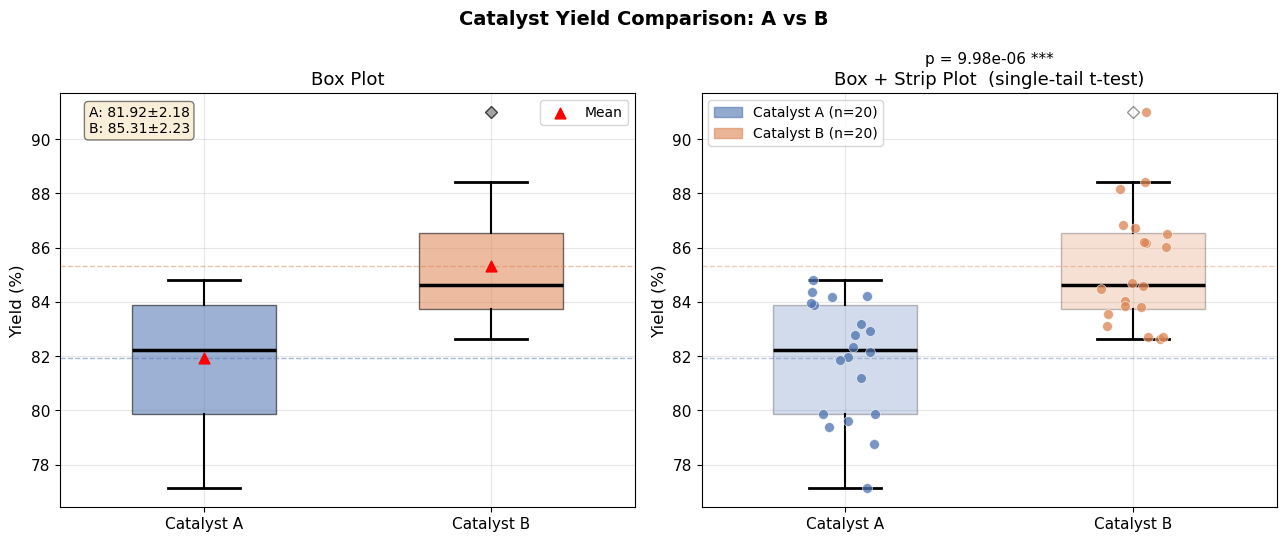

✓ 圖檔儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_02\figs\box_strip_plot.png


In [27]:
# ============================================================
# 箱型圖 + 帶狀圖 (Strip Plot) 視覺比較
# ============================================================
colors = ['#4C72B0', '#DD8452']
ALPHA_BOX = 0.55
ALPHA_DOT = 0.75

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Catalyst Yield Comparison: A vs B', fontsize=14, fontweight='bold')

# ---- 左圖：箱型圖 ----
ax = axes[0]
bp = ax.boxplot([yield_A, yield_B],
                labels=['Catalyst A', 'Catalyst B'],
                patch_artist=True,
                widths=0.5,
                medianprops=dict(color='black', lw=2.5),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=2),
                flierprops=dict(marker='D', ms=6, markerfacecolor='gray', alpha=0.7))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(ALPHA_BOX)

# 標示均值
ax.scatter([1, 2], [mean_A, mean_B], color='red', zorder=10, s=60,
            marker='^', label='Mean')
ax.axhline(mean_A, color=colors[0], ls='--', lw=1, alpha=0.5)
ax.axhline(mean_B, color=colors[1], ls='--', lw=1, alpha=0.5)
ax.set_ylabel('Yield (%)')
ax.set_title('Box Plot')
ax.legend(fontsize=10)
ax.text(0.05, 0.97,
        f'A: {mean_A:.2f}±{std_A:.2f}\nB: {mean_B:.2f}±{std_B:.2f}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ---- 右圖：箱型圖 + 帶狀圖疊加 ----
ax2 = axes[1]
bp2 = ax2.boxplot([yield_A, yield_B],
                   labels=['Catalyst A', 'Catalyst B'],
                   patch_artist=True, widths=0.5,
                   medianprops=dict(color='black', lw=2.5),
                   whiskerprops=dict(lw=1.5),
                   capprops=dict(lw=2),
                   flierprops=dict(marker='D', ms=6, alpha=0.4))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)

# 帶狀圖：x 位置加入隨機抖動 (Jitter)
rng_j = np.random.default_rng(0)
jitter_A = rng_j.uniform(-0.12, 0.12, size=n_A)
jitter_B = rng_j.uniform(-0.12, 0.12, size=n_B)
ax2.scatter(np.ones(n_A) + jitter_A, yield_A,
            color=colors[0], alpha=ALPHA_DOT, zorder=5, s=50, edgecolors='white', lw=0.5)
ax2.scatter(np.ones(n_B) * 2 + jitter_B, yield_B,
            color=colors[1], alpha=ALPHA_DOT, zorder=5, s=50, edgecolors='white', lw=0.5)

# t 檢定結果標記
p_display = p_one
sig_str = f'p = {fmt_p(p_display)}' + (' ***' if p_display < 0.001 else
                                         ' **'  if p_display < 0.01  else
                                         ' *'   if p_display < 0.05  else ' (ns)')
y_max = max(yield_A.max(), yield_B.max()) + 1.5
ax2.annotate('', xy=(2, y_max), xytext=(1, y_max),
             arrowprops=dict(arrowstyle='-', lw=2))
ax2.text(1.5, y_max + 0.3, sig_str, ha='center', fontsize=11, color='black')
ax2.axhline(mean_A, color=colors[0], ls='--', lw=1, alpha=0.4)
ax2.axhline(mean_B, color=colors[1], ls='--', lw=1, alpha=0.4)
ax2.set_ylabel('Yield (%)')
ax2.set_title("Box + Strip Plot  (single-tail t-test)")

# 圖例
patch_A = mpatches.Patch(color=colors[0], alpha=0.6, label=f'Catalyst A (n={n_A})')
patch_B = mpatches.Patch(color=colors[1], alpha=0.6, label=f'Catalyst B (n={n_B})')
ax2.legend(handles=[patch_A, patch_B], fontsize=10)

plt.tight_layout()
fig_path = FIG_DIR / 'box_strip_plot.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔儲存: {fig_path}")

---
### 8. 綜合結論摘要

In [28]:
# ============================================================
# 綜合結論摘要
# ============================================================
print("=" * 65)
print("  Unit14 Example 02 — 統計分析結果摘要")
print("=" * 65)
print(f"\n【數據摘要】")
print(f"  催化劑 A: mean = {mean_A:.3f}%, std = {std_A:.3f}%,  n = {n_A}")
print(f"  催化劑 B: mean = {mean_B:.3f}%, std = {std_B:.3f}%,  n = {n_B}")
print(f"  均值差 (B - A) = {mean_B - mean_A:.3f}%")

print(f"\n【信賴區間 (95%)】")
print(f"  A: [{ci_A[0]:.3f}, {ci_A[1]:.3f}]")
print(f"  B: [{ci_B[0]:.3f}, {ci_B[1]:.3f}]")

print(f"\n【Levene 變異數齊一性檢定】")
print(f"  W = {stat_levene:.4f}, p = {fmt_p(p_levene)}  → {conclusion_levene}")
print(f"  採用方法: {method_str}")

print(f"\n【獨立兩樣本 t 檢定（單尾，右尾）】")
print(f"  t = {t_stat:.4f}, df = {df_t:.2f}")
print(f"  單尾 p = {fmt_p(p_one)}  → {stat_conclusion}")

print(f"\n【效果量 Cohen's d】")
print(f"  d = {cohens_d:.4f}  ({effect_label})")

print(f"\n【工程建議】")
if p_one < alpha and abs(cohens_d) >= 0.5:
    print("  ✓ 統計顯著 + 效果量達中等以上，建議採用催化劑 B")
elif p_one < alpha and abs(cohens_d) < 0.5:
    print("  △ 統計顯著，但效果量偏小，需結合成本效益評估")
else:
    print("  ✗ 無統計顯著依據，維持使用催化劑 A")

print("\n【關鍵 Python 函式】")
key_funcs = [
    ("scipy.stats.t.interval()",   "計算均值信賴區間"),
    ("scipy.stats.sem()",          "計算標準誤 SEM"),
    ("scipy.stats.levene()",       "Levene 變異數齊一性檢定"),
    ("scipy.stats.ttest_ind()",    "獨立兩樣本 t 檢定"),
]
for fn, desc in key_funcs:
    print(f"  {fn:<35} → {desc}")
print("=" * 65)

  Unit14 Example 02 — 統計分析結果摘要

【數據摘要】
  催化劑 A: mean = 81.918%, std = 2.175%,  n = 20
  催化劑 B: mean = 85.306%, std = 2.226%,  n = 20
  均值差 (B - A) = 3.389%

【信賴區間 (95%)】
  A: [80.900, 82.936]
  B: [84.265, 86.348]

【Levene 變異數齊一性檢定】
  W = 0.0030, p = 0.9568  → p = 0.9568 ≥ α = 0.05，不拒絕 H0
  採用方法: Pooled-variance t-test (equal_var=True)

【獨立兩樣本 t 檢定（單尾，右尾）】
  t = 4.8691, df = 38.00
  單尾 p = 9.98e-06  → 拒絕 H0（顯著）

【效果量 Cohen's d】
  d = 1.5397  (大 (Large))

【工程建議】
  ✓ 統計顯著 + 效果量達中等以上，建議採用催化劑 B

【關鍵 Python 函式】
  scipy.stats.t.interval()            → 計算均值信賴區間
  scipy.stats.sem()                   → 計算標準誤 SEM
  scipy.stats.levene()                → Levene 變異數齊一性檢定
  scipy.stats.ttest_ind()             → 獨立兩樣本 t 檢定
